<a href="https://colab.research.google.com/github/kenichiy19/1CCPK-MLAM/blob/main/Sprints/2026_2/Sprint%203/SPRINT_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Integrantes**

Felipe Pereira Restivo - RM: 570712

Gabriel Rodrigues Zappelloni - RM: 572060

Kenichi Caio Yamamoto - RM: 569815

Maykon de Lima Silva – RM: 574022

Rodger Costa Rios - RM: 571438

# **Fonte dos dados**

**Life Expectancy (WHO)**:
- Kaggle: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who

# **Biblioteca**

In [1]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# **Código**

## Questão 01 - Probabilidade acima da Mediana

In [5]:
df = pd.read_csv('/content/Life Expectancy Data.csv')

variavel = 'Life expectancy '

mediana = df[variavel].median()
media = df[variavel].mean()
desvio_padrao = df[variavel].std()

probabilidade = 1 - stats.norm.cdf(mediana, media, desvio_padrao)

if probabilidade <= 0.10:
  classificacao = "Raro"
elif probabilidade < 0.50:
  classificacao = "Pouco provável"
elif probabilidade <= 0.90:
  classificacao = "Provável"
else:
  classificacao = "Quase certo"

print(f"Mediana: {mediana:.2f}")
print(f"Probabilidade de valores acima da mediana: {probabilidade * 100:.2f}%")
print(f"Classificação do evento: {classificacao}")

Mediana: 72.10
Probabilidade de valores acima da mediana: 38.14%
Classificação do evento: Pouco provável


## Questão 02 - Probabilidade no intervalo (média ± 2 desvios-padrão)

In [6]:
limite_inferior = media - (2 * desvio_padrao)
limite_superior = media + (2 * desvio_padrao)

prob_intervalo = stats.norm.cdf(limite_superior, media, desvio_padrao) - stats.norm.cdf(limite_inferior, media, desvio_padrao)

if prob_intervalo <= 0.10:
    classificacao = "Raro"
elif prob_intervalo < 0.50:
    classificacao = "Pouco provável"
elif prob_intervalo <= 0.90:
    classificacao = "Provável"
else:
    classificacao = "Quase certo"

print(f"Média: {media:.2f}")
print(f"Desvio-Padrão: {desvio_padrao:.2f}")
print(f"Limites do Intervalo: de {limite_inferior:.2f} a {limite_superior:.2f}")
print(f"Probabilidade no intervalo: {prob_intervalo * 100:.2f}%")
print(f"Classificação do evento: {classificacao}")

Média: 69.22
Desvio-Padrão: 9.52
Limites do Intervalo: de 50.18 a 88.27
Probabilidade no intervalo: 95.45%
Classificação do evento: Quase certo


## Questão 03 - Modelagem com Regressão Linear

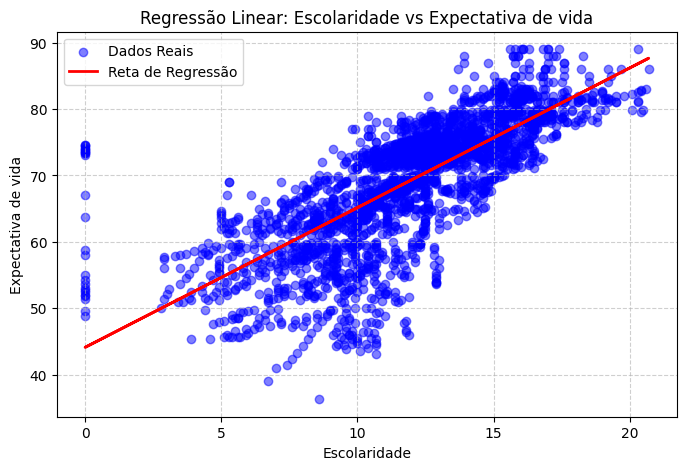

Coeficiente Angular (Inclinação): 2.10
Coeficiente Linear (Interseção): 44.11
Coeficiente de Determinação (R²): 0.5655


In [ ]:
dados_limpos = df[['Schooling', 'Life expectancy ']].dropna()

X = dados_limpos[['Schooling']]
y = dados_limpos['Life expectancy ']

modelo = LinearRegression()
modelo.fit(X, y)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.5, label='Dados Reais')
plt.plot(X, modelo.predict(X), color='red', linewidth=2, label='Reta de Regressão')

plt.title('Regressão Linear: Escolaridade vs Expectativa de vida')
plt.xlabel('Escolaridade')
plt.ylabel('Expectativa de vida')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Coeficiente Angular (Inclinação): {modelo.coef_[0]:.2f}")
print(f"Coeficiente Linear (Interseção): {modelo.intercept_:.2f}")
print(f"Coeficiente de Determinação (R²): {modelo.score(X, y):.4f}")

### **Interpretação (Item C)**

**1. Coeficiente Angular (Inclinação)**:

Para cada ano a mais de escolaridade média (Schooling), espera-se um aumento de aproximadamente 2,10 anos na expectativa de vida (Life expectancy), mantendo os demais fatores constantes.


**2. Coeficiente Linear (Interseção)**:

O intercepto representa o valor esperado da expectativa de vida (Y) quando a escolaridade (X) é igual a zero. Embora existam, de fato, 26 registros no dataset com escolaridade média igual a zero, a expectativa de vida real observada nesses casos varia entre aproximadamente 49 e 75 anos — valores bem superiores aos 44,11 anos previstos pelo modelo. Essa discrepância sugere que o valor previsto pelo intercepto não é confiável para esse extremo, provavelmente porque tais observações são raras e pouco representativas da tendência geral dos dados.

É possível, inclusive, que alguns desses registros de escolaridade igual a zero reflitam ausência de informação (dado faltante) e não uma escolaridade real nula, o que reforça a cautela na interpretação desse ponto do modelo.

**3. Coeficiente de Determinação**:

Aproximadamente 56,55% da variação na expectativa de vida pode ser explicada pelos anos de escolaridade, enquanto os 44,45% restantes se devem a outros fatores não incluídos no modelo.

## Questão 04 - Relação entre Estatística e Aprendizado de Máquina

### **Análise Exploratória e Seleção de Atributos**:
Antes de ajustar o modelo, a análise descritiva da variável Life expectancy (média = 69,22; desvio padrão = 9,52) permitiu compreender a dispersão dos dados, servindo de base tanto para essa etapa quanto para os exercícios de probabilidade realizados posteriormente. Já o coeficiente de correlação de Pearson (r = 0,752) atuou como a fase de validação do dataset: seu valor elevado indicou que as variáveis X (Escolaridade) e Y (Expectativa de vida) estão fortemente associadas, demonstrando que o avanço nos anos de estudo acompanha diretamente o aumento da longevidade da população. Essa ligação confirmou que a escolaridade é uma variável preditora relevante, justificando sua escolha para alimentar o modelo e comprovando a existência de um padrão consistente a ser capturado pela regressão linear.

### **Métricas e Avaliação de Desempenho**:
O coeficiente de determinação (R² = 0,5655) mostra que 56,55% da variação na expectativa de vida de uma população é explicada unicamente pelos anos de escolaridade daquela região. Nesse contexto, que se configura como um cenário das ciências sociais — no qual a expectativa de vida é influenciada por diversos fatores além da escolaridade —, o fato de uma única variável conseguir justificar mais da metade dessa variação comprova que ela se trata de uma das variáveis mais determinantes de toda a base. Levando tudo isso em consideração, o modelo de Regressão Linear desempenhou de forma satisfatória.

### **Análise Crítica e Escopo do Algoritmo**:
A interpretação do intercepto revela um limite importante do modelo. Embora existam 26 registros na base com escolaridade igual a zero, a expectativa de vida real observada nesses casos variou entre aproximadamente 48,9 e 74,6 anos — valores bem superiores aos 44,11 anos previstos pelo modelo. Essa discrepância indica que casos com escolaridade = 0 são raros e o modelo possui pouquíssima informação sobre esse extremo, levando à extrapolação.

Uma possível explicação para esse desvio está nos próprios países envolvidos: nações como Antigua and Barbuda e Montenegro não apresentam, na maioria dos anos analisados, características de ausência total de educação. Isso sugere que o valor zero pode não representar uma escolaridade real nula, mas sim um dado faltante disfarçado de zero.

De forma mais ampla, esse caso ilustra que modelos de Regressão Linear tendem a ser mais confiáveis na faixa dos 5 aos 15 anos de escolaridade, e menos confiáveis nas bordas, mesmo quando esses valores extremos existem tecnicamente na base de treino.